In [2]:
# ====================
# Imports and Setup
# ====================
# No installs needed if previous notebooks ran

import random
import pandas as pd
import numpy as np

from IPython.display import display, HTML
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

In [3]:
# -----------------------------
# Load Notebook One Artifacts
# -----------------------------

df = pd.read_csv("rag_base_dataset.csv")
embeddings = np.load("essay_embeddings.npy")

In [4]:
# ==========================
# Recreate Feature Pipeline
# ==========================

def vocab_richness(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df["word_count"] = df["full_text"].astype(str).apply(lambda x: len(x.split()))
df["vocab_richness"] = df["full_text"].astype(str).apply(vocab_richness)

feature_cols = ["word_count", "vocab_richness"]
X_features = df[feature_cols].fillna(0)

scaler = MinMaxScaler()
X_features_scaled = scaler.fit_transform(X_features)

# -------------------
# Retrieval Model
# -------------------

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
# ========================
# Retrieval Function
# ========================

def retrieve_similar_essays(new_text, top_k=5):

    new_embedding = model.encode([new_text])
    semantic_sim = cosine_similarity(new_embedding, embeddings)[0]

    new_word_count = len(new_text.split())
    new_vocab = vocab_richness(new_text)

    new_features_df = pd.DataFrame(
      [[new_word_count, new_vocab]],
      columns=feature_cols
    )

    new_features = scaler.transform(new_features_df)
    feature_sim = cosine_similarity(new_features, X_features_scaled)[0]

    # UPDATED WEIGHTS
    final_score = 0.6 * semantic_sim + 0.4 * feature_sim

    top_indices = np.argsort(final_score)[-top_k:][::-1]

    results = df.iloc[top_indices].copy()
    results["semantic_similarity"] = semantic_sim[top_indices]
    results["feature_similarity"] = feature_sim[top_indices]
    results["final_score"] = final_score[top_indices]

    return results

In [6]:
# ======================
# Core RAG Engine
# ======================

# This is where the fun begins!

# ------------------
# Helper Functions
# ------------------

# Extract Writing Signals
def analyze_essay(text):
    sentences = text.split(".")

    return {
        "length": len(text.split()),
        "sentences": len(sentences),
        "avg_sentence_length": len(text.split()) / max(len(sentences), 1),
        "vocab_richness": vocab_richness(text)
    }


# Compare to high-scoring Essays
def compare_to_top_essays(query_text, retrieved_df):

    query_stats = analyze_essay(query_text)

    high_score_df = retrieved_df[retrieved_df["score"] >= 4]

    if len(high_score_df) == 0:
        return "Not enough high-scoring essays to compare."

    avg_word_count = high_score_df["word_count"].mean()
    avg_vocab = high_score_df["vocab_richness"].mean()

    feedback = []

    if query_stats["length"] < avg_word_count:
        feedback.append("Your essay is shorter than higher-scoring essays. Consider expanding your ideas.")

    if query_stats["vocab_richness"] < avg_vocab:
        feedback.append("Try using more varied vocabulary to strengthen your writing.")

    if query_stats["avg_sentence_length"] < 10:
        feedback.append("Your sentences are quite short. Try combining ideas for more complex structure.")

    return feedback


Single Essay Evaluation:
score_std: 0.8944
predicted_score: 3.4000
score_range: 2.0000
unique_scores: 3.0000
groundedness_proxy: 3.2199


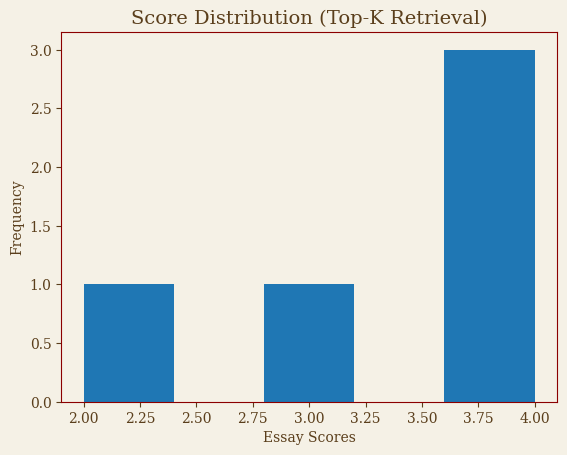

No similarity data available.


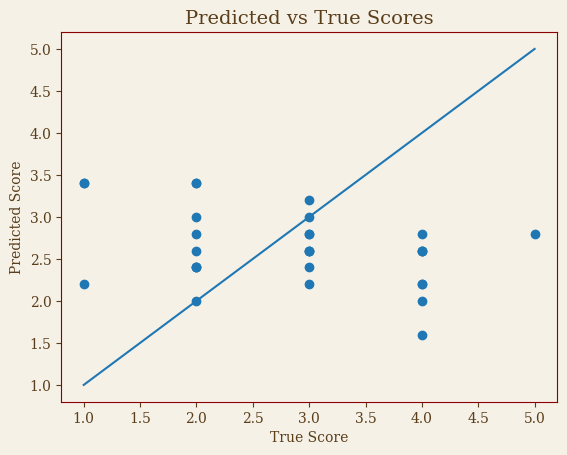

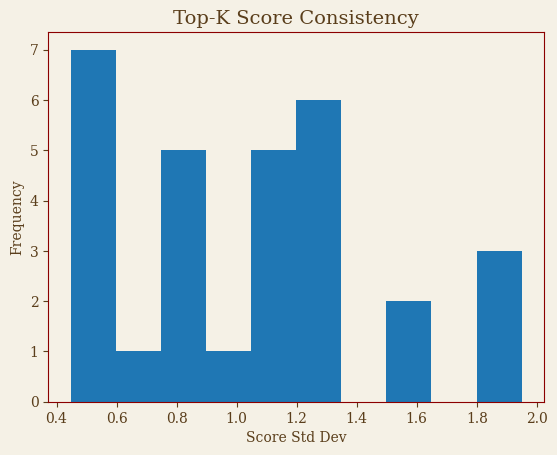

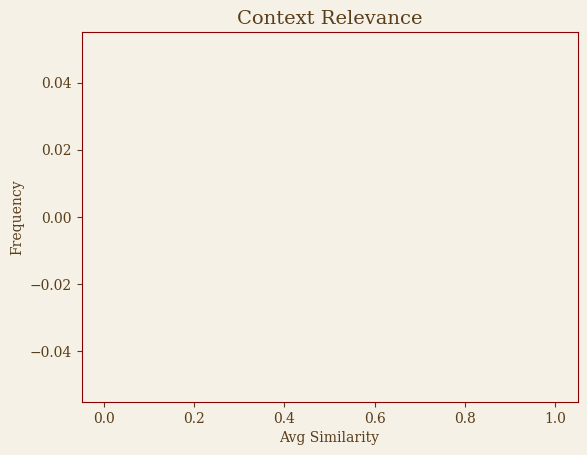

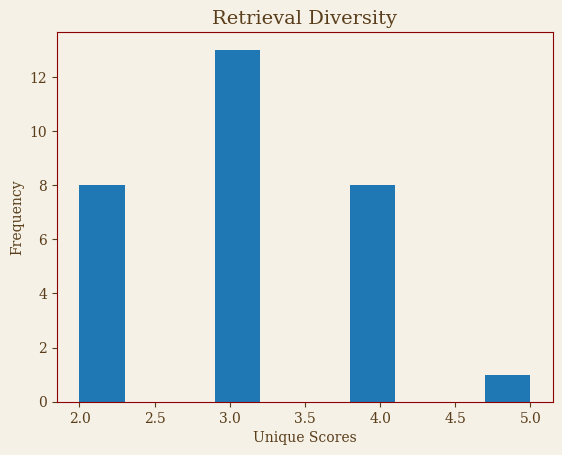

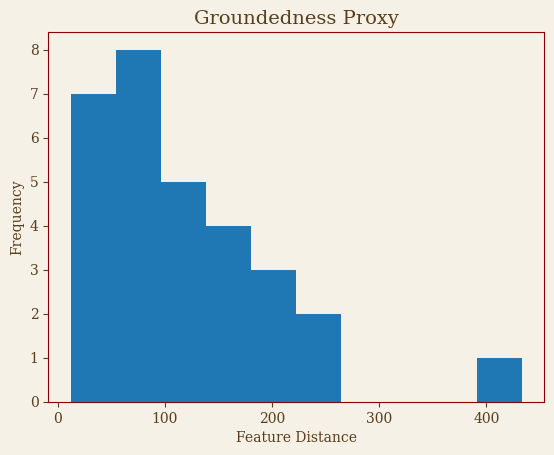

Avg Score Std (Consistency): 1.0579
Avg Similarity (Relevance): nan
Avg Diversity: 3.0667
Avg Groundedness Proxy: 118.9572

Interpretation Tips:
- Lower std = more consistent retrieval
- Higher similarity = better context relevance
- Lower groundedness proxy = better alignment with retrieved essays
- Diversity should be moderate (not too low, not too high)
- Alignment plot should cluster around diagonal



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [10]:
# ==========================================
# NOTEBOOK 4: RAG EVALUATION & DIAGNOSTICS
# ==========================================
# Theme: Warm classroom aesthetic
# Focus:
# - Top-K Retrieval Consistency
# - Score Alignment
# - Context Relevance
# - Groundedness (proxy)
# - Retrieval Diversity
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("ASAP2_train_sourcetexts.csv")
# ----------------------------------
# 🎨 Styling (Cream Classroom Theme)
# ----------------------------------
plt.rcParams.update({
    "figure.facecolor": "#f5f1e6",  # cream
    "axes.facecolor": "#f5f1e6",
    "axes.edgecolor": "#8b0000",    # dark red
    "axes.labelcolor": "#5a3e1b",   # brown
    "xtick.color": "#5a3e1b",
    "ytick.color": "#5a3e1b",
    "text.color": "#5a3e1b",
    "font.family": "serif"
})

# ----------------------------------
# 📊 Evaluation Functions
# ----------------------------------

def ensure_features(df):
    text_col = "full_text" if "full_text" in df.columns else None

    if text_col is None:
        raise ValueError("No text column found in retrieved data.")

    if "length" not in df.columns:
        df["length"] = df[text_col].apply(lambda x: len(str(x).split()))

    if "vocab_richness" not in df.columns:
        df["vocab_richness"] = df[text_col].apply(
            lambda x: len(set(str(x).split())) / len(str(x).split()) if len(str(x).split()) > 0 else 0
        )

    return df

def compute_query_features(text):
    words = text.split()

    length = len(words)

    # Vocabulary richness = unique words / total words
    unique_words = len(set(words))
    vocab_richness = unique_words / length if length > 0 else 0

    return {
        "length": length,
        "vocab_richness": vocab_richness
    }

def evaluate_rag(query_text, true_score=None):
    retrieved = retrieve_similar_essays(query_text)

    # ✅ ADD THIS LINE (critical fix)
    retrieved = ensure_features(retrieved)

    scores = retrieved["score"]
    similarities = retrieved["similarity"] if "similarity" in retrieved else None

    results = {}

    # 1. Top-K Consistency
    results["score_std"] = scores.std()

    # 2. Score Alignment
    predicted = scores.mean()
    results["predicted_score"] = predicted

    if true_score is not None:
        results["alignment_error"] = abs(predicted - true_score)

    # 3. Context Relevance
    if similarities is not None:
        results["avg_similarity"] = similarities.mean()

    # 4. Diversity
    results["score_range"] = scores.max() - scores.min()
    results["unique_scores"] = scores.nunique()

    # 5. Groundedness Proxy
    query_stats = compute_query_features(query_text)

    avg_length = retrieved["length"].mean()
    avg_vocab = retrieved["vocab_richness"].mean()

    groundedness = (
        abs(query_stats["length"] - avg_length) +
        abs(query_stats["vocab_richness"] - avg_vocab)
    )

    results["groundedness_proxy"] = groundedness

    return results, retrieved

# ----------------------------------
# 📈 Visualization Functions
# ----------------------------------

def plot_score_distribution(scores):
    plt.figure()
    plt.hist(scores, bins=5)
    plt.title("Score Distribution (Top-K Retrieval)", fontsize=14)
    plt.xlabel("Essay Scores")
    plt.ylabel("Frequency")
    plt.show()


def plot_similarity_vs_score(retrieved):
    if "similarity" not in retrieved:
        print("No similarity data available.")
        return

    plt.figure()
    plt.scatter(retrieved["similarity"], retrieved["score"])
    plt.title("Similarity vs Score", fontsize=14)
    plt.xlabel("Semantic Similarity")
    plt.ylabel("Essay Score")
    plt.show()


def plot_alignment(predicted_scores, true_scores):
    plt.figure()
    plt.scatter(true_scores, predicted_scores)
    plt.plot([min(true_scores), max(true_scores)],
             [min(true_scores), max(true_scores)])
    plt.title("Predicted vs True Scores", fontsize=14)
    plt.xlabel("True Score")
    plt.ylabel("Predicted Score")
    plt.show()

# ----------------------------------
# 🧪 Batch Evaluation
# ----------------------------------

def batch_evaluate(df, sample_size=25):
    sampled = df.sample(sample_size, random_state=42)

    predicted_scores = []
    true_scores = []
    stds = []
    similarities = []
    diversity = []
    groundedness = []

    for _, row in sampled.iterrows():
        res, retrieved = evaluate_rag(row["full_text"], row.get("score"))

        predicted_scores.append(res["predicted_score"])
        true_scores.append(row.get("score", np.nan))
        stds.append(res["score_std"])

        if "avg_similarity" in res:
            similarities.append(res["avg_similarity"])

        diversity.append(res["unique_scores"])
        groundedness.append(res["groundedness_proxy"])

    return {
        "predicted": predicted_scores,
        "true": true_scores,
        "std": stds,
        "similarity": similarities,
        "diversity": diversity,
        "groundedness": groundedness
    }

# ----------------------------------
# 📊 Aggregate Plots
# ----------------------------------

def plot_metric_distribution(metric, title, xlabel):
    plt.figure()
    plt.hist(metric, bins=10)
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.show()

# ----------------------------------
# 🚀 Run Evaluation
# ----------------------------------

# Single Example
example = df["full_text"].iloc[0]
results, retrieved = evaluate_rag(example)

print("Single Essay Evaluation:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

plot_score_distribution(retrieved["score"])
plot_similarity_vs_score(retrieved)

# Batch Evaluation
metrics = batch_evaluate(df, sample_size=30)

plot_alignment(metrics["predicted"], metrics["true"])
plot_metric_distribution(metrics["std"], "Top-K Score Consistency", "Score Std Dev")
plot_metric_distribution(metrics["similarity"], "Context Relevance", "Avg Similarity")
plot_metric_distribution(metrics["diversity"], "Retrieval Diversity", "Unique Scores")
plot_metric_distribution(metrics["groundedness"], "Groundedness Proxy", "Feature Distance")

# Summary Table
summary = {
    "Avg Score Std (Consistency)": np.mean(metrics["std"]),
    "Avg Similarity (Relevance)": np.mean(metrics["similarity"]),
    "Avg Diversity": np.mean(metrics["diversity"]),
    "Avg Groundedness Proxy": np.mean(metrics["groundedness"])
}

for k, v in summary.items():
    print(f"{k}: {v:.4f}")

# ----------------------------------
# 📝 Interpretation Guide
# ----------------------------------
print("""
Interpretation Tips:
- Lower std = more consistent retrieval
- Higher similarity = better context relevance
- Lower groundedness proxy = better alignment with retrieved essays
- Diversity should be moderate (not too low, not too high)
- Alignment plot should cluster around diagonal
""")
